In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
from keras.models import Sequential
from keras.layers import LSTM, RepeatVector, TimeDistributed, Dense


### Load Dataset

In [27]:
df = pd.read_csv(r"C:\Users\admin\Downloads\equipment_sensors.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

df.head()


,temp,vibration,rpm,pressure
timestamp,,,,
2024-01-01 00:00:00,62.483571,12.798711,1466.241086,280.921924
2024-01-01 00:01:00,59.308678,11.849267,1492.774066,291.396150
2024-01-01 00:02:00,63.238443,10.119261,1460.379004,295.863945
2024-01-01 00:03:00,67.615149,8.706126,1484.601924,318.876877
2024-01-01 00:04:00,58.829233,11.396447,1405.319267,305.565531


### Data Cleaning

In [32]:
print(df.isnull().sum())

df = df.fillna(method='ffill')
df = df.drop_duplicates()
def remove_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[~((data < lower) | (data > upper)).any(axis=1)]

df_clean = remove_outliers_iqr(df)

print("Original shape:", df.shape)
print("After outlier removal:", df_clean.shape)
df = df_clean


temp         0
vibration    0
rpm          0
pressure     0
dtype: int64
Original shape: (969, 4)
After outlier removal: (967, 4)


C:\Users\admin\AppData\Local\Temp\ipykernel_13988\1124529058.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


### Visualization

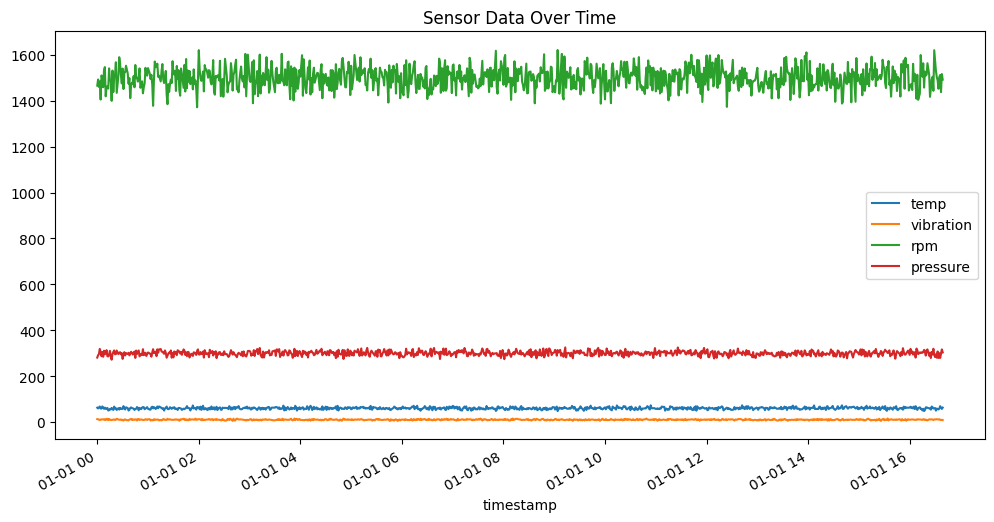

In [33]:
df.plot(figsize=(12,6))
plt.title("Sensor Data Over Time")
plt.show()


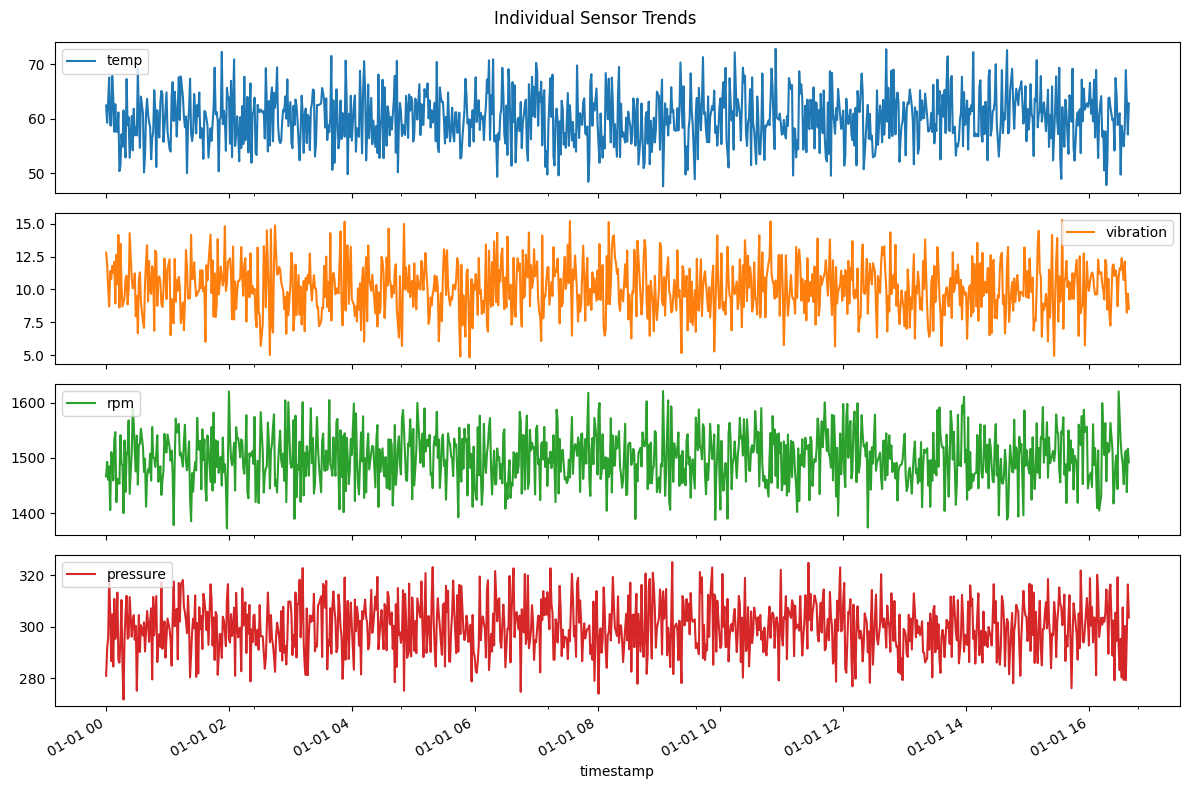

In [34]:
df[['temp','vibration','rpm','pressure']].plot(subplots=True, figsize=(12,8), title="Individual Sensor Trends")
plt.tight_layout()
plt.show()


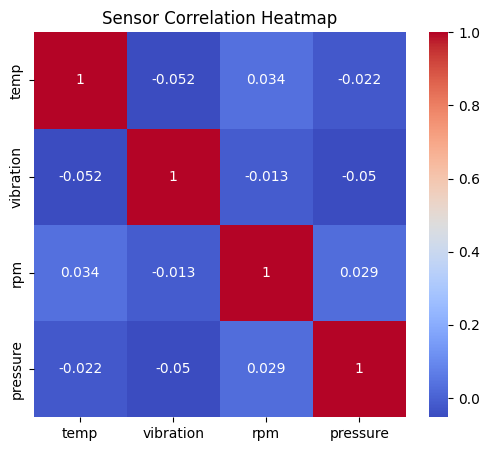

In [35]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Sensor Correlation Heatmap")
plt.show()


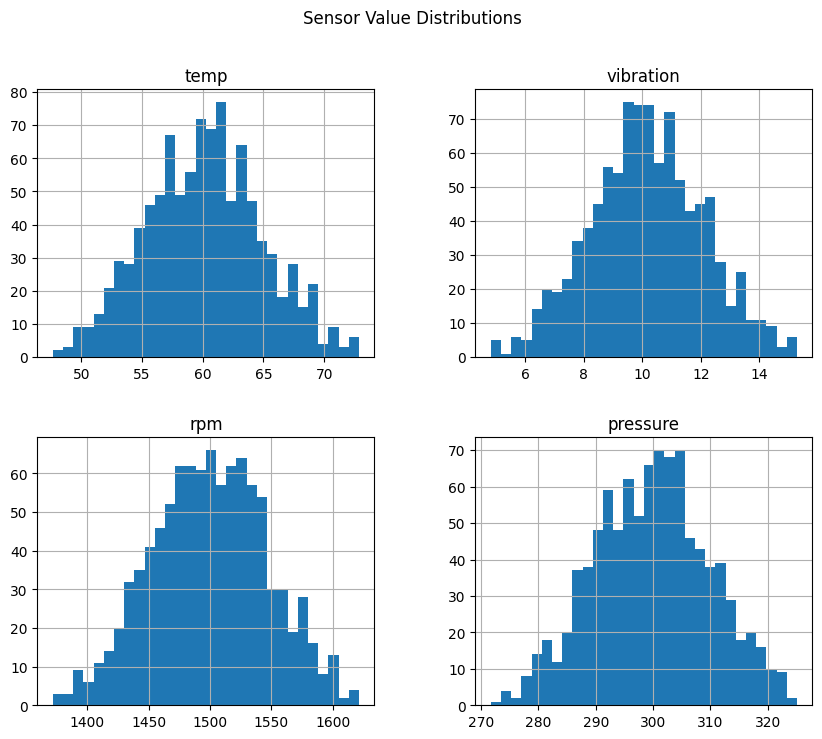

In [36]:
df.hist(figsize=(10,8), bins=30)
plt.suptitle("Sensor Value Distributions")
plt.show()


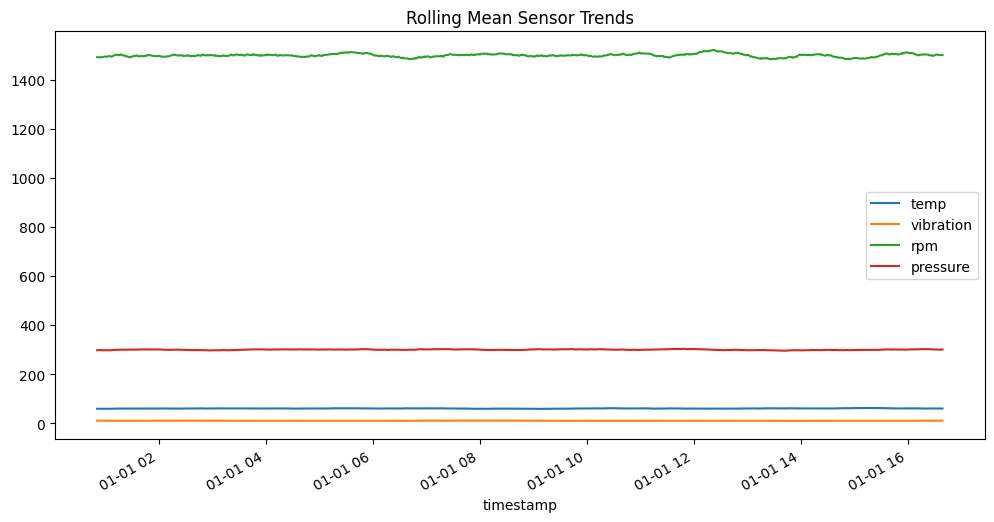

In [37]:
rolling = df.rolling(window=50).mean()
rolling.plot(figsize=(12,6))
plt.title("Rolling Mean Sensor Trends")
plt.show()


### Normalization

In [38]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)


### ISOLATION FOREST MODEL

### Isolation Forest

In [39]:
iso_model = IsolationForest(contamination=0.05, random_state=42)
df['anomaly_iforest'] = iso_model.fit_predict(scaled_data)

df['anomaly_iforest'] = df['anomaly_iforest'].map({1:0, -1:1})


### Isolation Forest Visualization

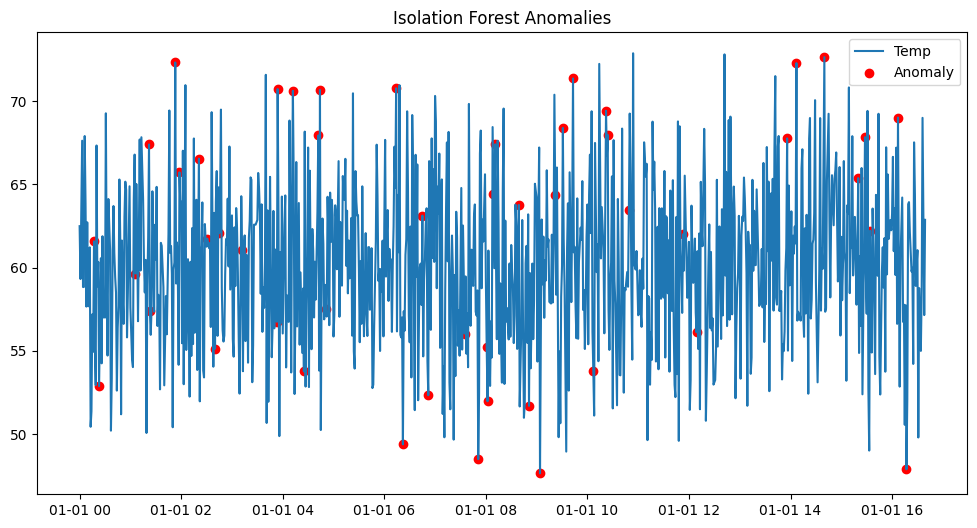

In [40]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['temp'], label='Temp')
plt.scatter(df[df['anomaly_iforest']==1].index,
            df[df['anomaly_iforest']==1]['temp'],
            color='red', label='Anomaly')
plt.legend()
plt.title("Isolation Forest Anomalies")
plt.show()


### LSTM AUTOENCODER

### Sequence Creation

In [41]:
def create_sequences(data, seq_len):
    X = []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
    return np.array(X)

seq_len = 30
X = create_sequences(scaled_data, seq_len)


### Build LSTM Autoencoder

In [42]:
model = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_len, X.shape[2]), return_sequences=False),
    RepeatVector(seq_len),
    LSTM(64, activation='relu', return_sequences=True),
    TimeDistributed(Dense(X.shape[2]))
])

model.compile(optimizer='adam', loss='mse')
model.summary()


C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 64)                  │          17,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector_1 (RepeatVector)       │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 30, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 30, 4)               │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,948 (199.02 KB)

 Trainable params: 50,948 (199.02 KB)

 Non-trainable params: 0 (0.00 B)

### Train Model

In [43]:
model.fit(X, X, epochs=10, batch_size=32, validation_split=0.1)


Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.1158 - val_loss: 0.0537
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0468 - val_loss: 0.0444
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0405 - val_loss: 0.0397
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0374 - val_loss: 0.0378
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0355 - val_loss: 0.0362
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0350 - val_loss: 0.0363
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0349 - val_loss: 0.0360
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0347 - val_loss: 0.0359
Epoch 9/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0348 - val_loss: 0.0358
Epoch 10/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0347 - val_loss: 0.0357


### Reconstruction Error

In [44]:
X_pred = model.predict(X)
mse = np.mean(np.power(X - X_pred, 2), axis=(1,2))

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


### Threshold Selection

In [45]:
threshold = np.percentile(mse, 95)
threshold


0.0411556981384933

### LSTM Anomaly Detection

In [46]:
lstm_anomalies = mse > threshold


### Add Final Anomaly Column

In [47]:
df['anomaly_lstm'] = 0
df.iloc[seq_len:, df.columns.get_loc("anomaly_lstm")] = lstm_anomalies.astype(int)


### Visualization

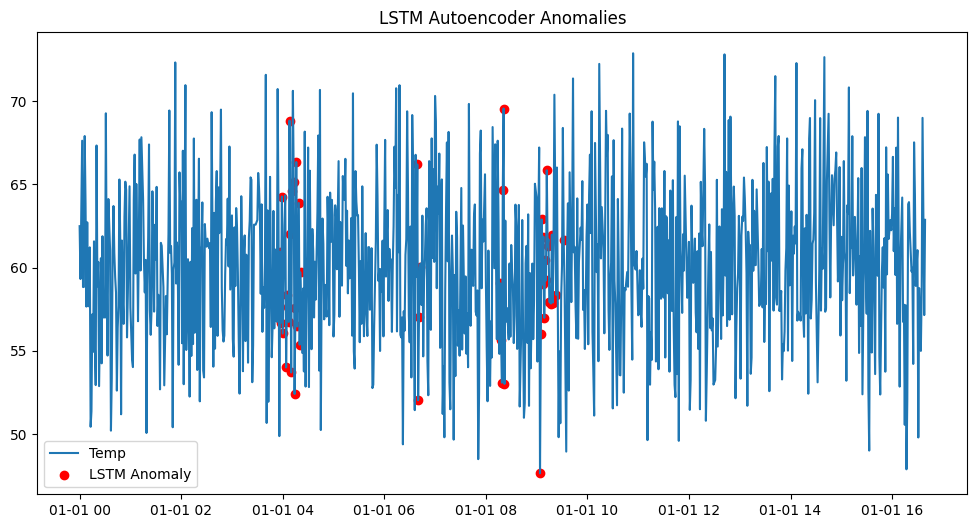

In [48]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['temp'], label="Temp")
plt.scatter(df[df['anomaly_lstm']==1].index,
            df[df['anomaly_lstm']==1]['temp'],
            color='red', label="LSTM Anomaly")
plt.legend()
plt.title("LSTM Autoencoder Anomalies")
plt.show()


### FINAL OUTPUT DATA

In [49]:
df.head(20)


,temp,vibration,rpm,pressure,anomaly_iforest,anomaly_lstm
timestamp,,,,,,
2024-01-01 00:00:00,62.483571,12.798711,1466.241086,280.921924,0,0
2024-01-01 00:01:00,59.308678,11.849267,1492.774066,291.396150,0,0
2024-01-01 00:02:00,63.238443,10.119261,1460.379004,295.863945,0,0
2024-01-01 00:03:00,67.615149,8.706126,1484.601924,318.876877,0,0
2024-01-01 00:04:00,58.829233,11.396447,1405.319267,305.565531,0,0
2024-01-01 00:05:00,58.829315,10.786971,1510.664685,286.645184,0,0
2024-01-01 00:06:00,67.896064,11.790386,1500.060274,304.860363,0,0
2024-01-01 00:07:00,63.837174,11.270344,1459.145568,284.526960,0,0
2024-01-01 00:08:00,57.652628,12.099105,1532.962283,310.826911,0,0


### SUMMARY METRICS

In [50]:
print("Isolation Forest Anomalies:", df['anomaly_iforest'].sum())
print("LSTM Anomalies:", df['anomaly_lstm'].sum())


Isolation Forest Anomalies: 49
LSTM Anomalies: 47


In [51]:
total = len(df)
iforest_anom = df['anomaly_iforest'].sum()
lstm_anom = df['anomaly_lstm'].sum()

print("Total Records:", total)
print("Isolation Forest Anomalies:", iforest_anom, "(", round(iforest_anom/total*100,2), "% )")
print("LSTM Anomalies:", lstm_anom, "(", round(lstm_anom/total*100,2), "% )")


Total Records: 967
Isolation Forest Anomalies: 49 ( 5.07 % )
LSTM Anomalies: 47 ( 4.86 % )


In [52]:
summary = pd.DataFrame({
    "Model": ["Isolation Forest", "LSTM Autoencoder"],
    "Anomalies Detected": [iforest_anom, lstm_anom],
    "Percentage (%)": [
        round(iforest_anom/total*100,2),
        round(lstm_anom/total*100,2)
    ]
})

summary


,Model,Anomalies Detected,Percentage (%)
0,Isolation Forest,49,5.07
1,LSTM Autoencoder,47,4.86


In [23]:
df.to_csv("final_anomaly_output.csv")
